In [1]:

import numpy as np 
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import linear_model 
# plt.style.use('ggplot')


# sns.set(style="ticks", context="talk")
# sns.set_theme(palette="viridis", style="ticks")
# plt.style.use("dark_background")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 12

# Sensitivity analysis of the model

### Introduction:

Model parameters are often chosen while building based on what feels right at the moment. As the number of parameters grow, it becomes really hard to disceratain which parameters actually affect model scores significantly. 
Our sensitivity analysis is mainly to understand which parameters play a role in echolocation in groups, especially when it comes to utilizing our consistency based approach to do so.

### Methods:



## 0. Setting up the model null
### Entropy stats
The description of the entropy of the system are described below. Among all our model parameters only speed affects the entropy.


In [2]:
null_model_data = "../../Data/AnalysisData/null_model_scores.csv"
df_null_model = pd.read_csv(null_model_data)
df_null_model["identifier"] = "null"

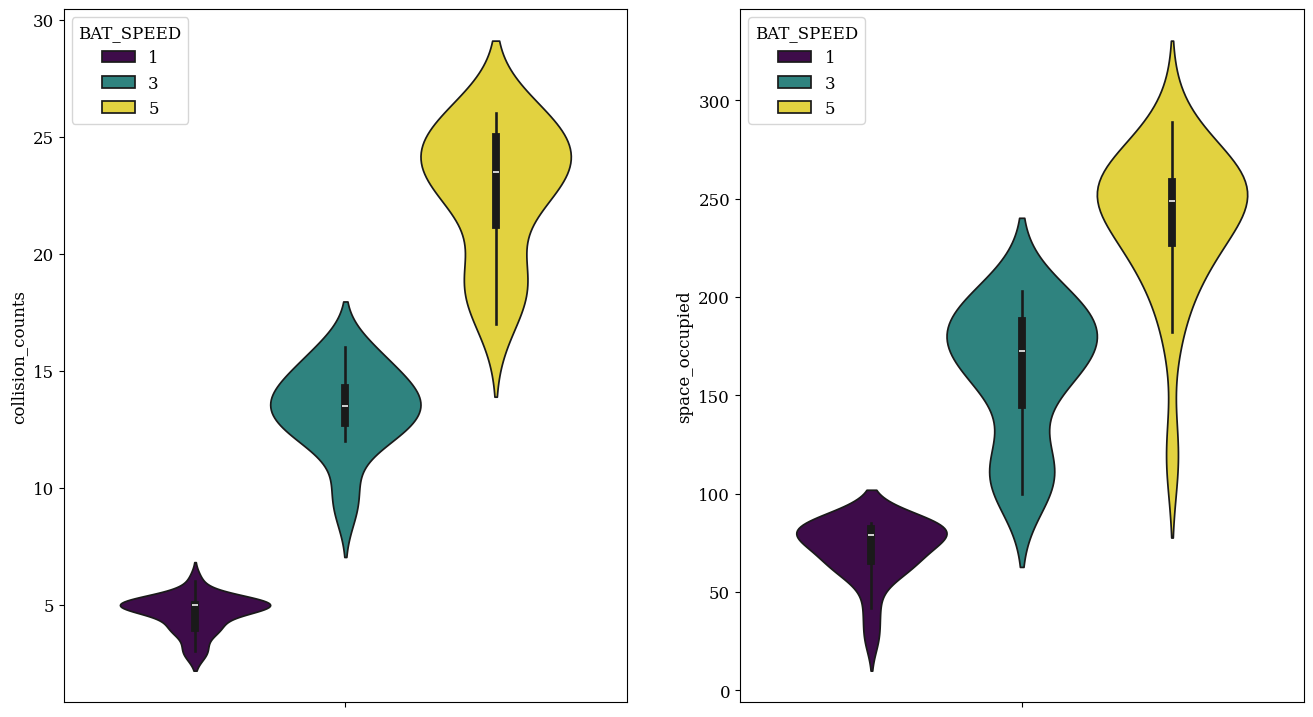

In [3]:
%matplotlib inline
plt.figure(figsize=(16,9))
plt.subplot(1,2,1)
sns.violinplot(df_null_model, hue="BAT_SPEED", y="collision_counts", palette="viridis")
plt.subplot(1,2,2)
sns.violinplot(df_null_model, hue="BAT_SPEED", y="space_occupied", palette="viridis")
plt.show()

In [4]:
mean_null_collisions = df_null_model.groupby("BAT_SPEED")["collision_counts"].mean()
mean_null_collisions

BAT_SPEED
1     4.65
3    13.35
5    22.70
Name: collision_counts, dtype: float64

Our model output has to be significantly different than the null in order for it to be good enough. 

This only applies to collision counts. Model has to collide significantly less often than the null model. For space occupied it doesn't matter.

# 1. Analyzing data
### 1.0 Understanding parameters
Let's first look at overall variation of scores over all our parameters. 


In [5]:

analysis_data_dir = r"../../Data/AnalysisData/sensitivity_analysis_data.csv"
df_overall_model = pd.read_csv(analysis_data_dir)
df_overall_model["TEMPORAL_MASKING_FN_TYPE_ONE_HOT"] = [1 if i=="full" else 0 for i in df_overall_model["TEMPORAL_MASKING_FN_TYPE"]]
df_overall_model.to_csv("sensitivity_analysis_data_for_R.csv")
df_overall_model["identifier"] = "treatment"

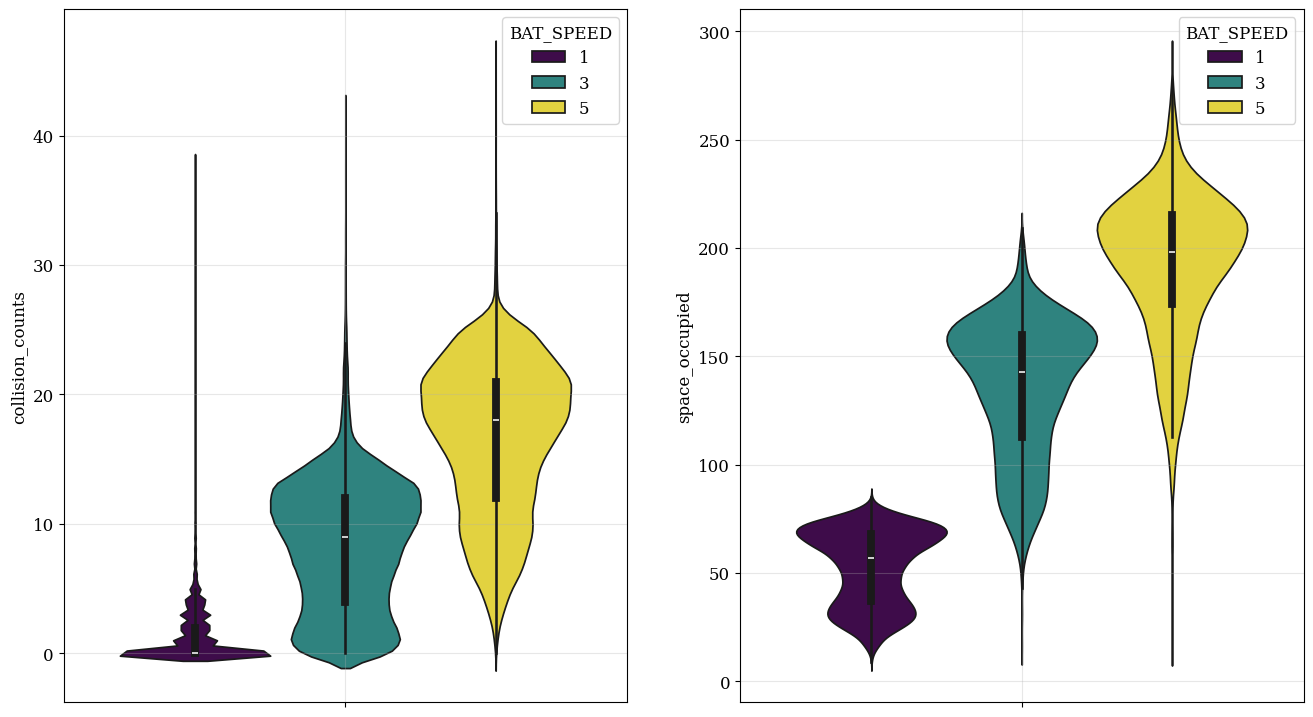

In [6]:
%matplotlib inline
plt.figure(figsize=(16,9))
plt.subplot(1,2,1)
sns.violinplot(df_overall_model, hue="BAT_SPEED", y="collision_counts", palette="viridis")
plt.grid(True, alpha=0.3)
plt.subplot(1,2,2)
sns.violinplot(df_overall_model, hue="BAT_SPEED", y="space_occupied", palette="viridis")
plt.grid(True, alpha=0.3)

<Figure size 800x800 with 0 Axes>

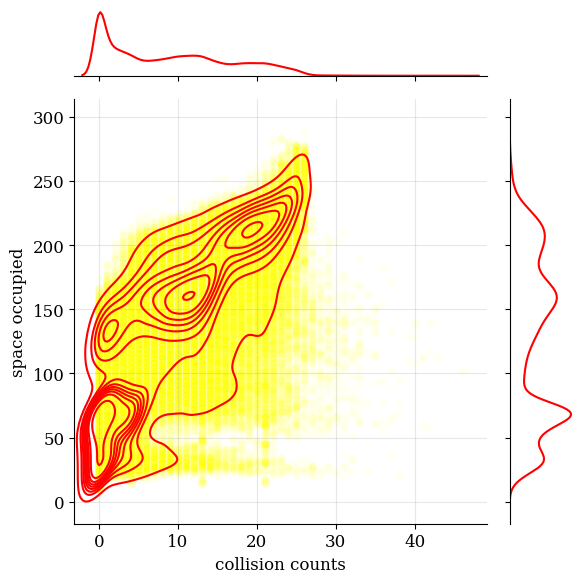

In [7]:
plt.figure(figsize=(8,8))
sns.jointplot(df_overall_model, x="collision_counts", y="space_occupied", kind="kde", color="red")
sns.scatterplot(df_overall_model, x="collision_counts", y="space_occupied", alpha =0.05, color="yellow")
plt.ylabel("space occupied")
plt.xlabel("collision counts")
# plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Text(0.5, 0, 'sensorimotor model type')

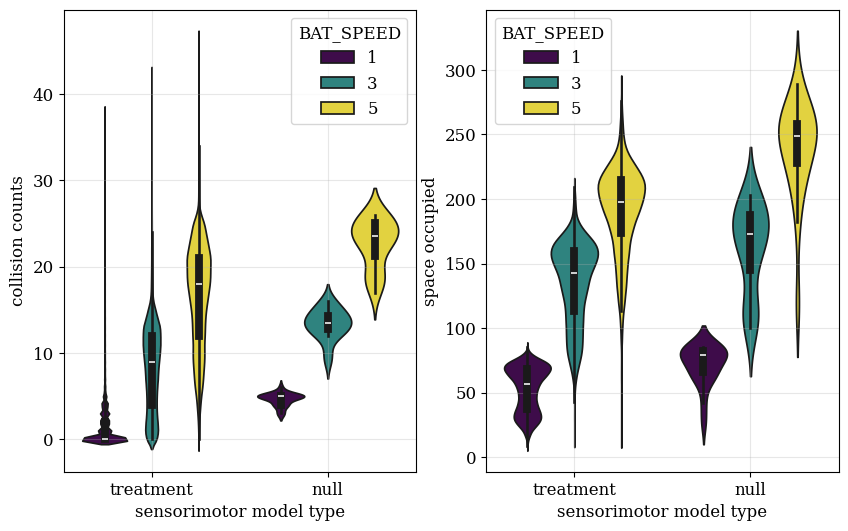

In [23]:
# lets merge to see them next to each other
df_merged = pd.concat((df_overall_model,df_null_model))
%matplotlib inline
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.violinplot(df_merged, hue="BAT_SPEED", y="collision_counts", x="identifier", palette="viridis")
plt.grid(True, alpha=0.3)
plt.ylabel("collision counts")
plt.xlabel("sensorimotor model type")
plt.subplot(1,2,2)
sns.violinplot(df_merged, hue="BAT_SPEED", y="space_occupied", x="identifier", palette="viridis")
plt.grid(True, alpha=0.3)
plt.ylabel("space occupied")
plt.xlabel("sensorimotor model type")

In [9]:
# resample up the null
# df_merged_resampled = df_merged
# for i in range(1400):
#     df_merged_resampled = pd.concat((df_merged_resampled, df_null_model))

In [10]:
# sns.jointplot(df_merged_resampled, x="collision_counts", y="space_occupied",hue="identifier", kind="kde", palette="rainbow")

Overall seems like a lot of points are below the null, positive results! Model works for a lot of parameter combinations. Also, note however a lot of points are well over null. Its important to acknowledge that. 

Space occupied will ofc be less than the null because a model that avoids walls is by default going to explore lesser space. 

## 1.1 What does the best case look like?
Best case is ofcourse 0 collisions here. Let's see what the variance of the parameters is like when collision rate is 0.

Text(0.5, 0, 'bat speed')

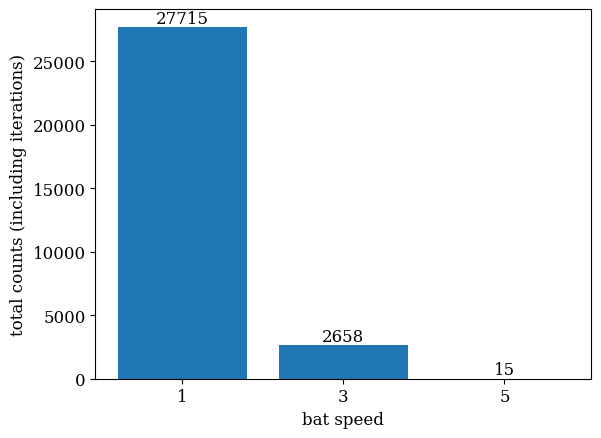

In [11]:
df_zero_collisions = df_overall_model[(df_overall_model["collision_counts"]==0)]
bat_speeds = [1,3,5]
counts_zero_collision = [len(df_zero_collisions[df_zero_collisions["BAT_SPEED"]==i]) for i in bat_speeds]
fig, ax = plt.subplots()
bat_speeds = ["1", "3", "5"]
ax = ax.bar(bat_speeds, counts_zero_collision)
plt.bar_label(ax)
plt.ylabel("total counts (including iterations)")
plt.xlabel("bat speed")

<Axes: xlabel='BAT_SPEED', ylabel='space_occupied'>

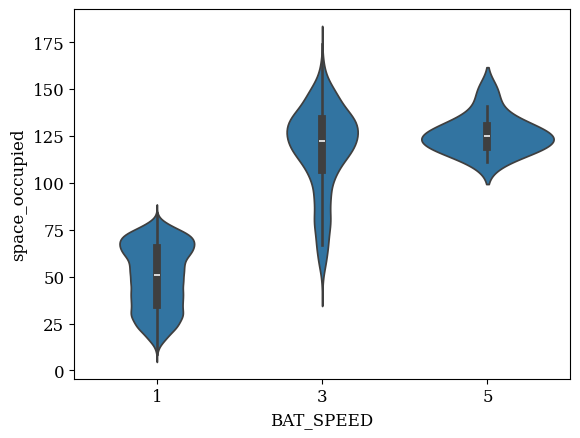

In [12]:
sns.violinplot(df_zero_collisions, x="BAT_SPEED", y="space_occupied")

In [13]:
# these are the parameters that were varied during the simulations
varying_params = np.array([
    "CALL_DURATION",
    "CALL_RATE_FAST",
    "HEARING_THRESHOLD",
    "CALL_DIRECTIONALITY",
    "TEMPORAL_MASKING_FN_TYPE",
    "TIME_DELAY_FOR_DIRECTION_CHANGE",
    "BAT_RADIAL_RESOLUTION",
    "MEMORY_WINDOW_FOR_CONSISTENCY",
    "BAT_FRONTAL_RANGE",
])
labels = np.array(['call duration (s)', 'fast call rate (Hz)', 'hearing threshold (dB)', 'call directionality', 'temporal masking function', 'time spent listening (s)', 'distance resolution (s)', 'memory window size', 'frontal range (degrees)'])
number_of_params = len(varying_params)

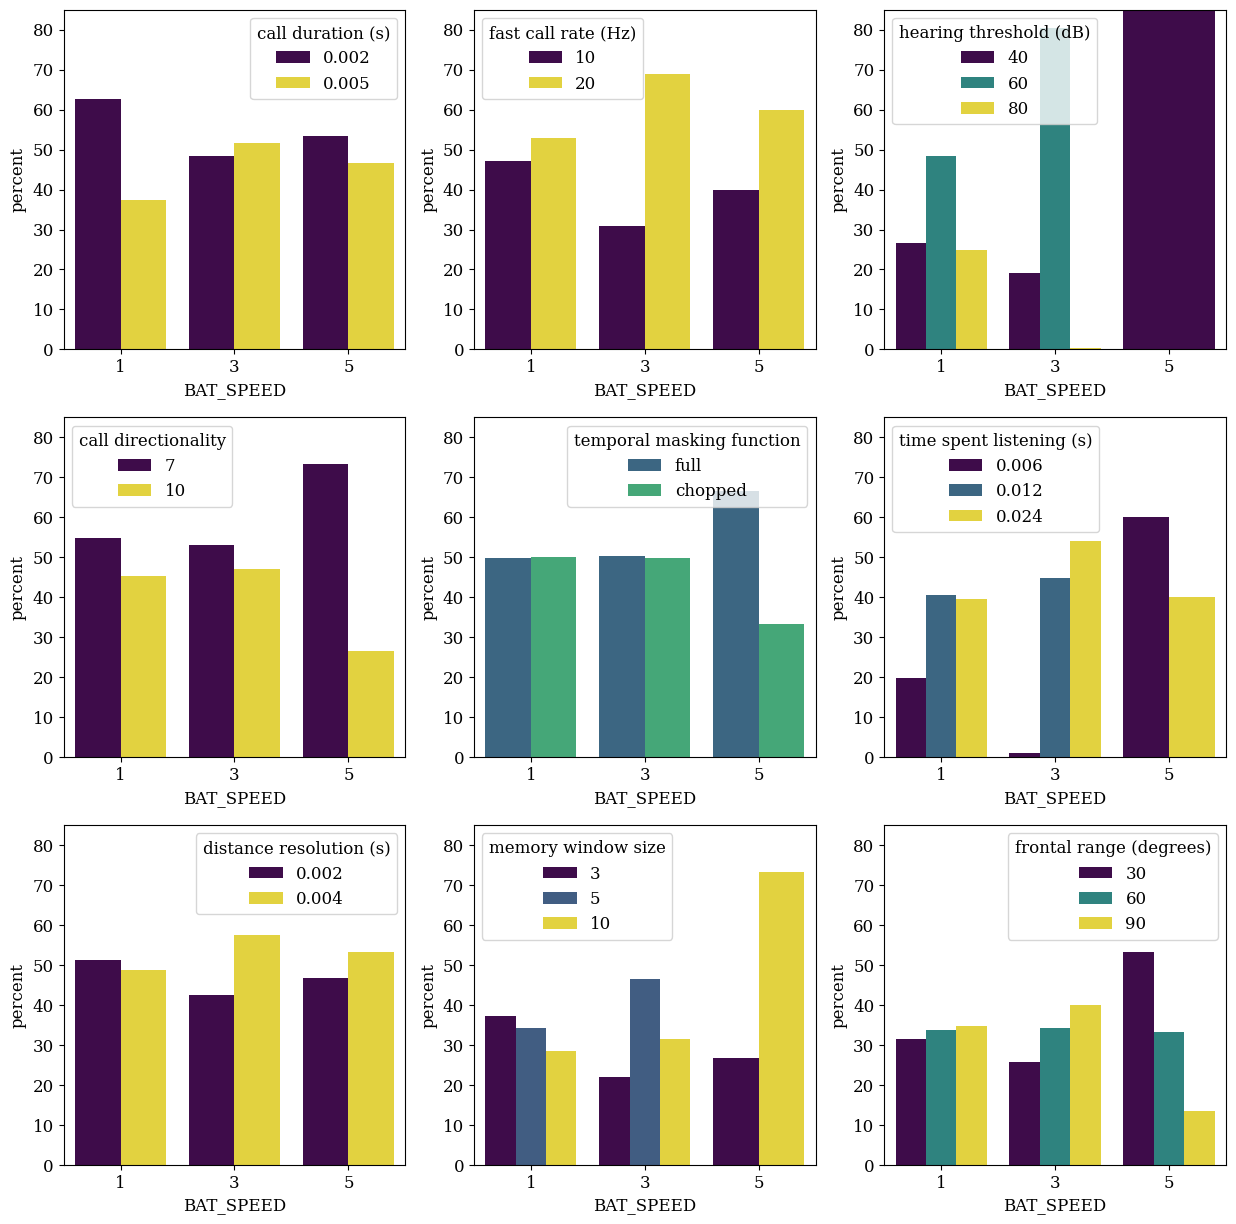

In [25]:

%matplotlib inline
plt.figure(figsize=(15,15))
number_of_subfigs = int(np.ceil(number_of_params/3))
bat_speeds = [1,3,5]
for bat_speed in bat_speeds:
    legend = True if bat_speed == 1 else False
    for i, param in enumerate(varying_params):
        df_zero_collisions = df_overall_model[(df_overall_model["collision_counts"]==0) & (df_overall_model["BAT_SPEED"]==bat_speed)]
        plt.subplot(3,number_of_subfigs,i+1)
        sns.countplot(df_zero_collisions, x="BAT_SPEED", hue=param, stat="percent", legend=legend, palette= "viridis")
        plt.ylim(0,85)
        plt.legend(title= labels[list(varying_params).index(param)])


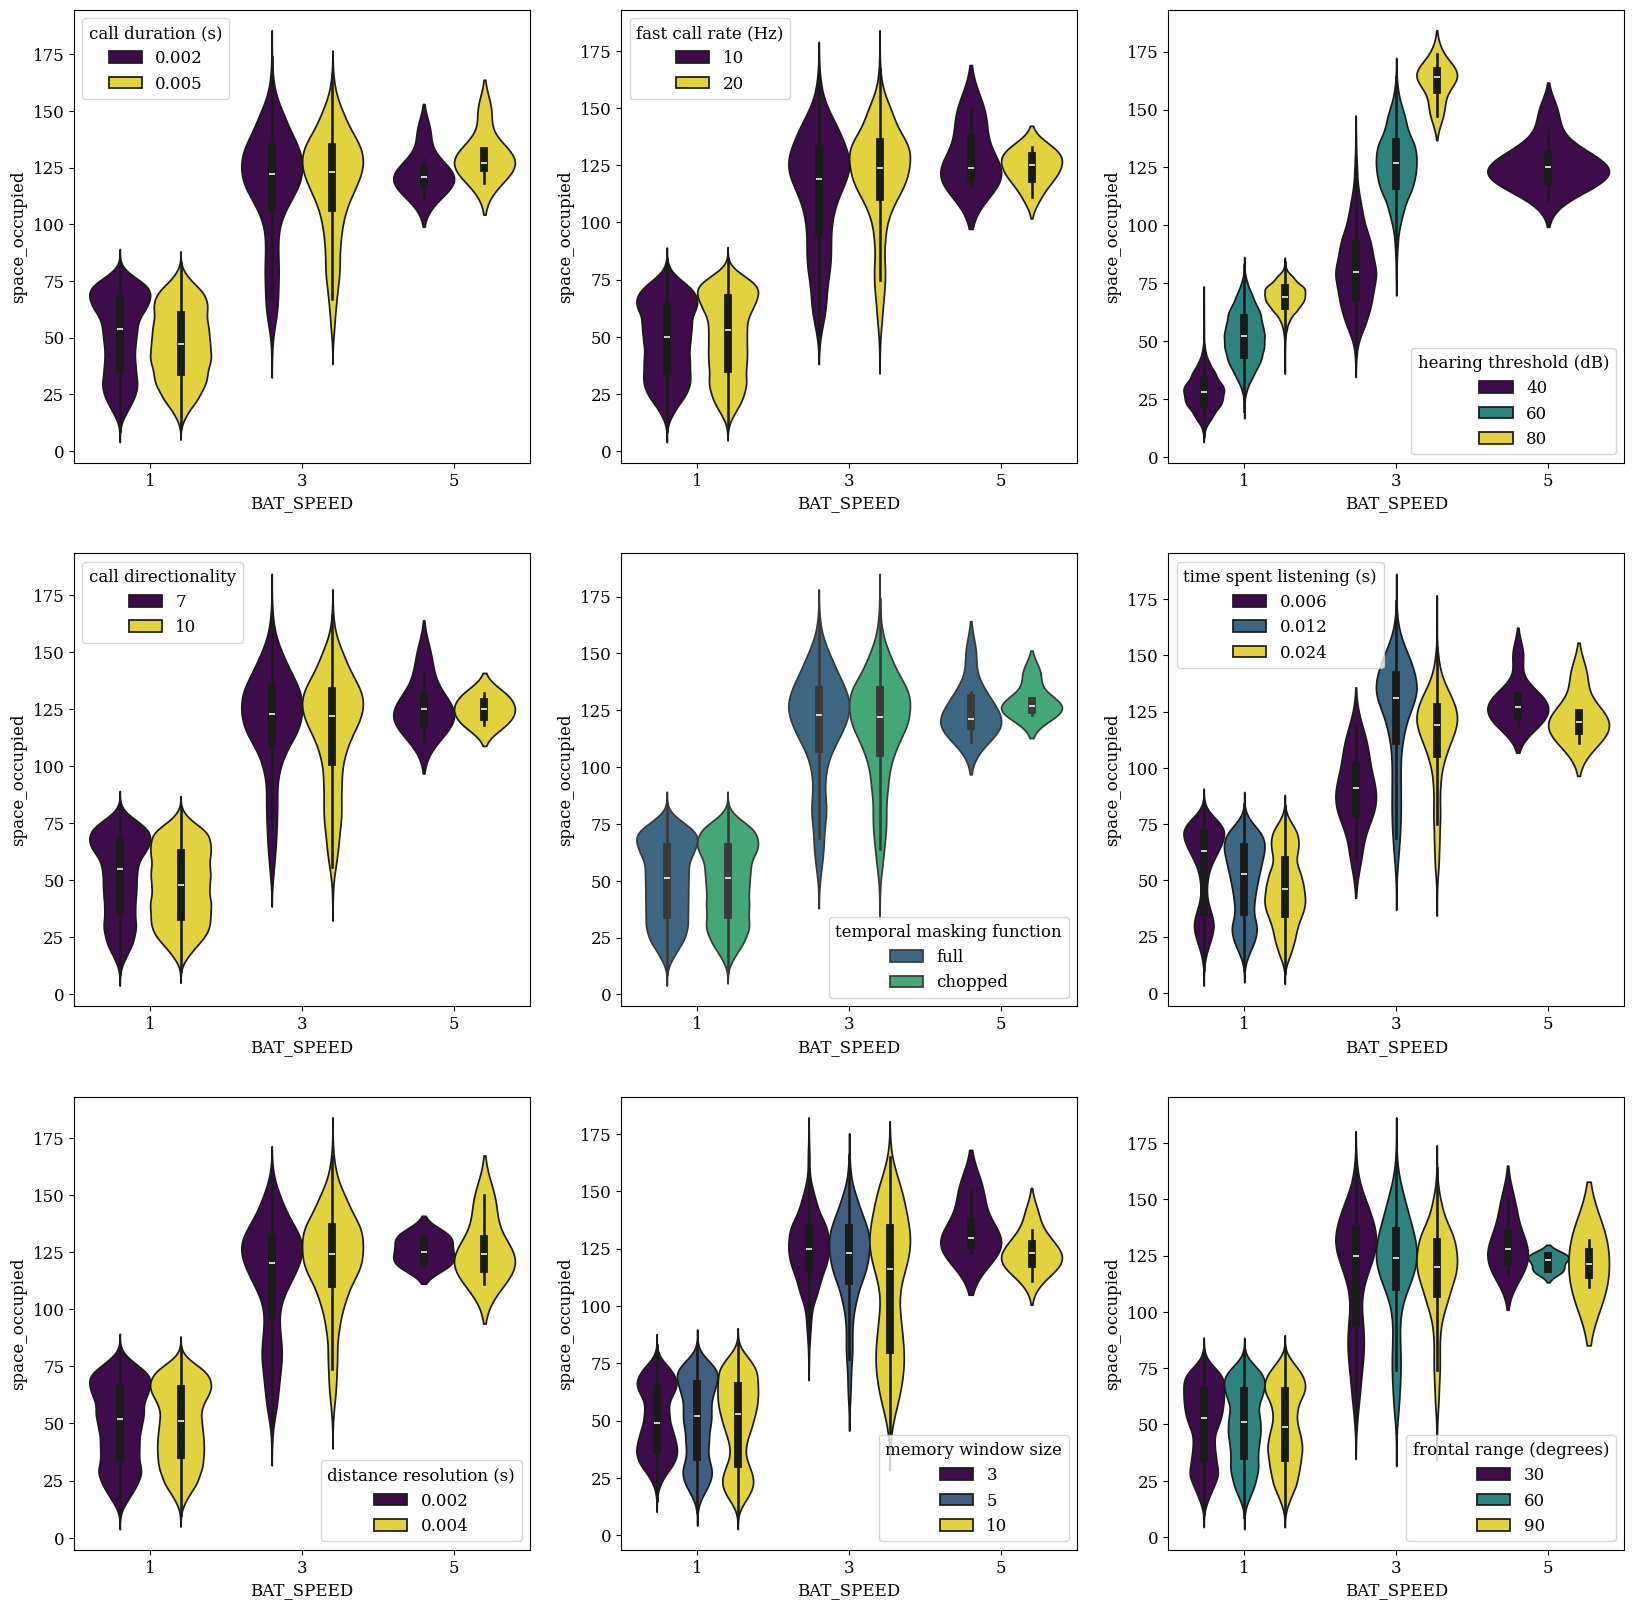

In [15]:
%matplotlib inline
plt.figure(figsize=(20,20))
number_of_subfigs = int(np.ceil(number_of_params/3))
bat_speeds = [1,3,5]
for bat_speed in bat_speeds:
    legend = True if bat_speed == 1 else False
    for i, param in enumerate(varying_params):
        df_zero_collisions = df_overall_model[(df_overall_model["collision_counts"]==0) & (df_overall_model["BAT_SPEED"]==bat_speed)]
        plt.subplot(3,number_of_subfigs,i+1)
        sns.violinplot(df_zero_collisions, x="BAT_SPEED", y="space_occupied", hue=param, legend=legend, palette= "viridis")
        plt.legend(title= labels[list(varying_params).index(param)])
        # plt.ylim(0,85)

** EXPLAIN RESULTS HERE **

That wasnt very fair for bat speed of 5 cause base collision rate is ofc high when speed is high!

Let's fix how we think of low collisions. Now low collisions would mean less than quater of the mean collision count of the null model.

In [16]:
df_low_collisions = df_overall_model
mean_null_collisions = {1:1, 3:4, 5:10}
df_low_collisions["mean_null_collision_counts"] = [mean_null_collisions[i] for i in df_low_collisions["BAT_SPEED"]]
# df_zero_collisions = df_overall_model[(df_overall_model["collision_counts"]<) & (df_overall_model["BAT_SPEED"]==bat_speed)]
df_low_collisions = df_low_collisions[df_low_collisions["collision_counts"]<df_low_collisions["mean_null_collision_counts"]]
df_low_collisions

,Unnamed: 0.1,Unnamed: 0,space_occupied,collision_counts,collision_rate,calling_effort,iteration_label,SOUND_SPEED,SIM_DURATION,TIME_STEP,...,BEHAVIOUR_RULE,CONTROLLER_TYPE,STORE_HEARING,JAMMER_RESOLUTION,TEMPORAL_MASKING_FN_TYPE,OUTPUT_DIR_FOR_SIMULATION,PARAM_LABEL,TEMPORAL_MASKING_FN_TYPE_ONE_HOT,identifier,mean_null_collision_counts
1,1,1,67,0,0.000000,300,iteration_number_1,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment,1
3,3,3,69,0,0.000000,301,iteration_number_3,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment,1
4,4,4,67,0,0.000000,299,iteration_number_4,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment,1
5,5,5,67,0,0.000000,298,iteration_number_5,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment,1
8,8,8,69,0,0.000000,301,iteration_number_8,343,30,0.001,...,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155495,15,15,139,1,0.003833,389,iteration_number_15,343,30,0.001,...,consistency,presence,no,1,chopped,/sensitivity_analysis/paramset_3015/,paramset_3015,0,treatment,4
155496,16,16,128,2,0.009833,362,iteration_number_16,343,30,0.001,...,consistency,presence,no,1,chopped,/sensitivity_analysis/paramset_3015/,paramset_3015,0,treatment,4
155497,17,17,127,1,0.005600,358,iteration_number_17,343,30,0.001,...,consistency,presence,no,1,chopped,/sensitivity_analysis/paramset_3015/,paramset_3015,0,treatment,4
155498,18,18,124,2,0.009667,357,iteration_number_18,343,30,0.001,...,consistency,presence,no,1,chopped,/sensitivity_analysis/paramset_3015/,paramset_3015,0,treatment,4


In [17]:
import pandas as pd

def get_lowest_5_percent(df):
    # Group by bat speed and calculate 5th percentile for each group
    percentiles = df.groupby('BAT_SPEED')['collision_counts'].quantile(0.10)

    # Filter rows where collisions are <= 5th percentile for their bat speed
    lowest_5_percent = df[df.apply(
        lambda row: row['collision_counts'] <= percentiles[row['BAT_SPEED']],
        axis=1
    )]

    return lowest_5_percent

# Usage
df_low_collisions = get_lowest_5_percent(df_overall_model)


Text(0.5, 0, 'bat speed')

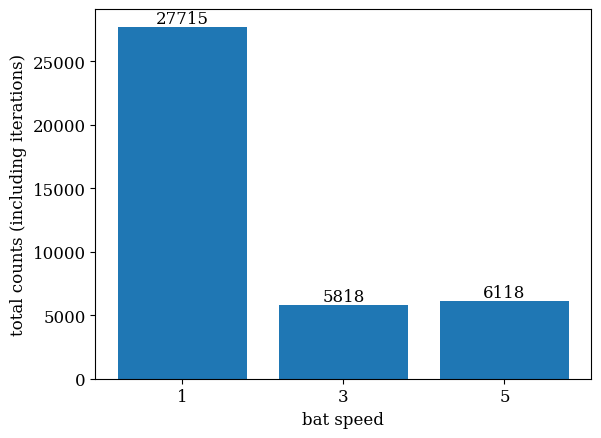

In [18]:
bat_speeds = [1,3,5]
counts_low_collision = [len(df_low_collisions[df_low_collisions["BAT_SPEED"]==i]) for i in bat_speeds]
fig, ax = plt.subplots()
bat_speeds = ["1", "3", "5"]
ax = ax.bar(bat_speeds, counts_low_collision)
plt.bar_label(ax)
plt.ylabel("total counts (including iterations)")
plt.xlabel("bat speed")

<Axes: ylabel='space_occupied'>

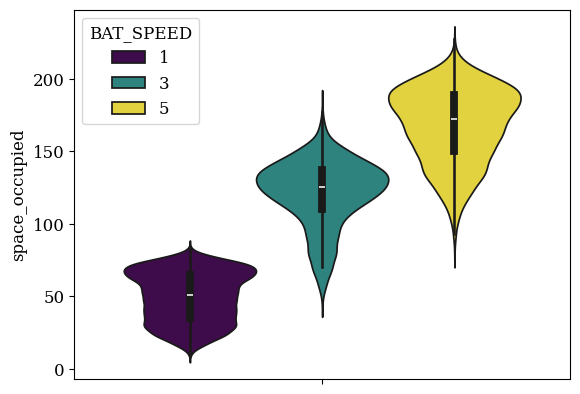

In [19]:
sns.violinplot(df_low_collisions, hue="BAT_SPEED", y="space_occupied", palette="viridis")

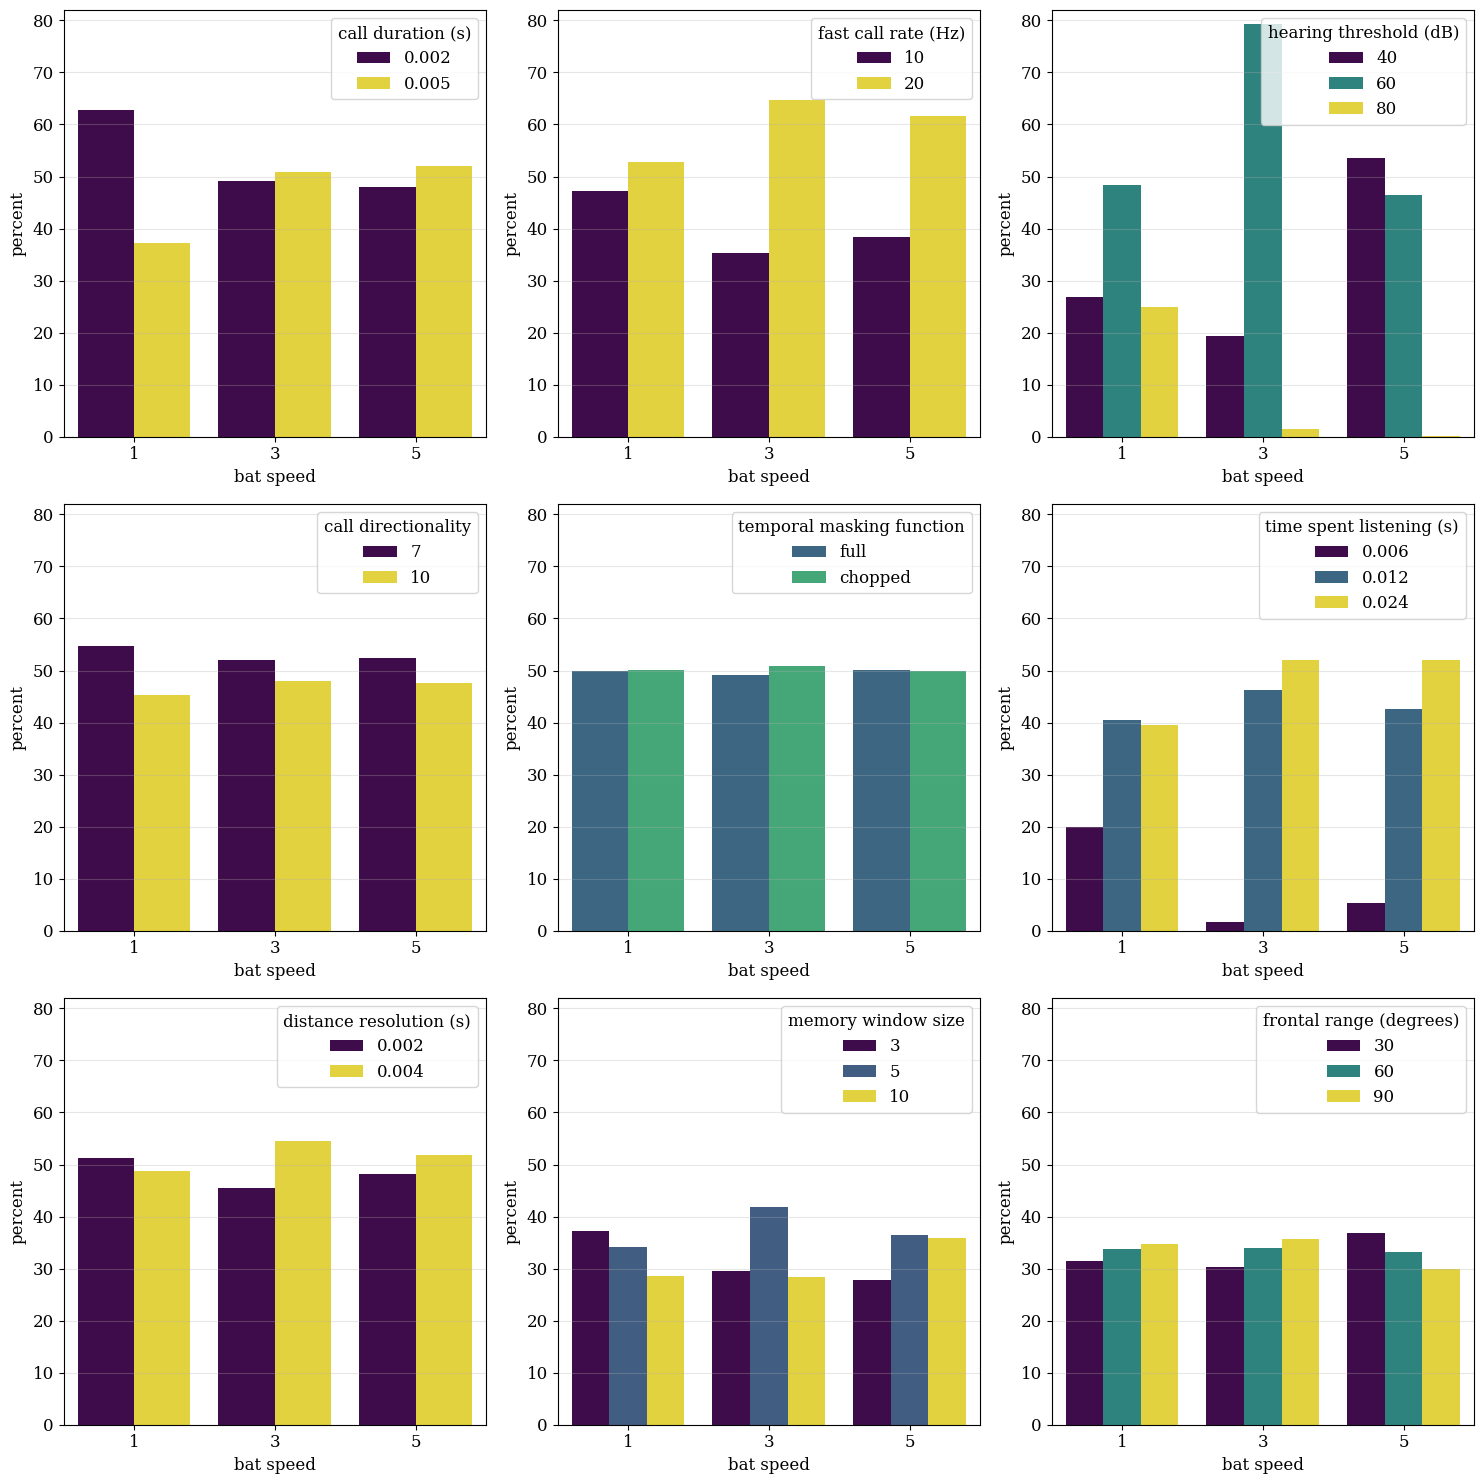

In [30]:

%matplotlib inline
plt.figure(figsize=(15,15))
number_of_subfigs = int(np.ceil(number_of_params/3))
bat_speeds = [1,3,5]
for bat_speed in bat_speeds:
    legend = True if bat_speed == 1 else False
    for i, param in enumerate(varying_params):
        df_low_collisions_given_bat_speed = df_low_collisions[(df_low_collisions["BAT_SPEED"]==bat_speed)]
        plt.subplot(3,number_of_subfigs,i+1)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        sns.countplot(df_low_collisions_given_bat_speed, x="BAT_SPEED", hue=param, stat="percent", legend=legend, palette="viridis")
        plt.ylim(0,82)
        plt.xlabel("bat speed")
        # plt.legend(title="balls")
        plt.legend(title= labels[list(varying_params).index(param)])
        


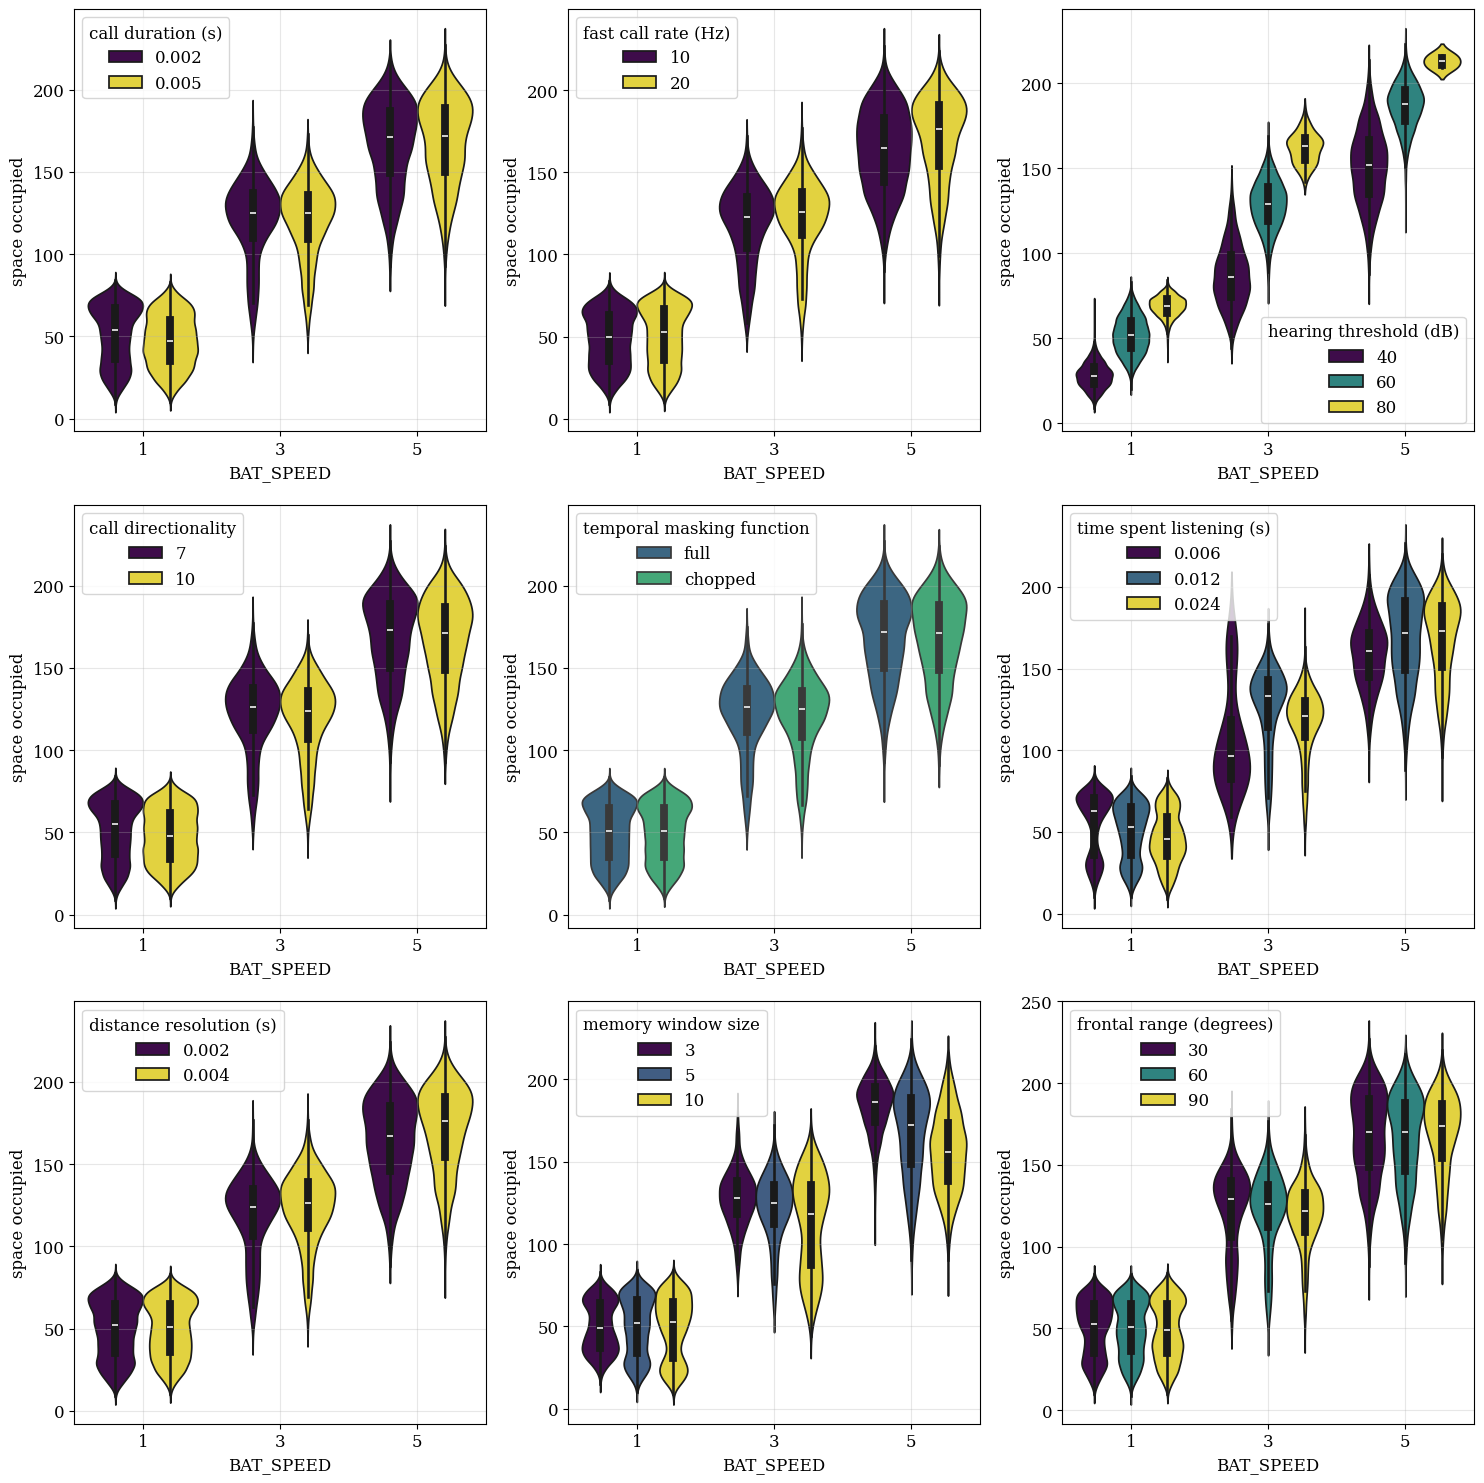

In [32]:
%matplotlib inline
plt.figure(figsize=(15,15))
number_of_subfigs = int(np.ceil(number_of_params/3))
bat_speeds = [1,3,5]
for bat_speed in bat_speeds:
    legend = True if bat_speed == 1 else False
    for i, param in enumerate(varying_params):
        df_low_collisions_given_bat_speed = df_low_collisions[(df_low_collisions["BAT_SPEED"]==bat_speed)]
        plt.subplot(3,number_of_subfigs,i+1)
        sns.violinplot(df_low_collisions_given_bat_speed, x="BAT_SPEED", hue=param, y="space_occupied", legend=legend, palette="viridis")
        plt.legend(title= labels[list(varying_params).index(param)])
        plt.grid(True, alpha=0.3)
        plt.ylabel("space occupied")
        plt.tight_layout()

now that we identified the key variables with respect to collision counts, lets try to look at how the distributions look like for these varibles.